# TCN Autoencoder (Temporal Convolutional Network) for Cassini CDA Mass Spectra

This notebook implements a **TCN (Temporal Convolutional Network) Autoencoder** to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why TCN?
Standard CNNs often struggle with long-range dependencies in sequential data unless they are very deep. TCNs use **dilated convolutions** to exponentially increase the receptive field, allowing the network to "see" the entire spectrum width (low mass to high mass) with fewer parameters than a fully connected network and better stability than RNNs/LSTMs.

### Architecture Highlights:
- **Dilated Causal Convolutions**:  Exponentially increasing dilation factors ($d=1, 2, 4, 8...$) allow the model to capture both local peak shapes and global spectral patterns.
- **Residual Connections**: Help train deeper networks by allowing gradients to flow through more easily.
- **Latent Space**: A compressed continuous vector representation of the spectrum.

### Pipeline Steps:
1. **Data Loading**: Load Parquet files containing the spectra.
2. **Preprocessing**: Savitzky-Golay filtering → log transformation → normalization (Same as VQ-VAE for comparison).
3. **Model Architecture**: TCN Encoder-Decoder with adjustable depth and compression.
4. **Training**: Minimize Reconstruction Loss (MSE).
5. **Evaluation**: Ground truth metrics (Silhouette, Linear Probe, Reconstruction Error).

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import os

# ==========================================
# CONFIGURATION
# ==========================================
Input_Length = 1000  
Batch_Size = 128
Learning_Rate = 1e-3
Epochs = 20

# TCN Specific Architecture Choices (Adjustable)
# Deeper Architecture: 6 Layers to force global abstraction and reduce spatial dimensions before flattening
Latent_Dim = 32         # Dimension of the bottleneck (compressed representation)
Channel_List = [32, 64, 64, 128, 256, 256, 256] # Channels for each TCN block level
Kernel_Size = 5          # Size of the convolution kernel
Dropout_Rate = 0.1       # Regularization
Slope = 0.1              # LeakyReLU slope

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly.

In [14]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_pre2008277_train_lvl2.parquet'

try:
    if os.path.exists(file_path):
        df = pd.read_parquet(file_path)
        print(f"Loaded data shape: {df.shape}")
        
        # Extract spectral data
        if 'spectrum' in df.columns:
            print("Found 'spectrum' column.")
            # Ensure it's a stack of numpy arrays
            spectra_raw = np.stack(df['spectrum'].values)
        else:
            raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")
    else:
        print(f"Warning: File {file_path} not found. Creating dummy data for demonstration.")
        # Create dummy data if file doesn't exist (for template purposes)
        df = pd.DataFrame({
            'class': np.random.choice(['Type A', 'Type B', 'Type C'], size=1000),
            'spectrum': [np.random.rand(1000).astype(np.float32) for _ in range(1000)]
        })
        spectra_raw = np.stack(df['spectrum'].values)
        print("Created dummy data.")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

# 1.1 Analyze Classes
if 'class' in df.columns:
    print("\nClass distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
else:
    print("Column 'class' not found in dataframe.")

Loaded data shape: (19820, 6)
Found 'spectrum' column.

Class distribution:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64


### 2. Preprocessing
Standard preprocessing pipeline used across our spectral analysis models to ensure fair comparison.
*   **Target Length:** 1000 bins.
*   **Denoising:** Savitzky-Golay filter.
*   **Log1p:** Compress dynamic range.
*   **Normalization:** Scale to 0-1 range.

Preprocessing data...
Processed Data Shape: (19820, 1000)
Calculating class weights (Balanced)...
  Using Sklearn 'balanced' Class Weighting
  Class weights generated. (Max weight: 619.38, Min weight: 0.10)
    Most common (Noise): weight=0.1026 (count=12077)
    Rarest (3-K): weight=56.31 (count=22)
    Rarest (2-X): weight=412.92 (count=3)
    Rarest (X): weight=619.38 (count=2)

  Visualizing Class Weights...
Processed Data Shape: (19820, 1000)
Calculating class weights (Balanced)...
  Using Sklearn 'balanced' Class Weighting
  Class weights generated. (Max weight: 619.38, Min weight: 0.10)
    Most common (Noise): weight=0.1026 (count=12077)
    Rarest (3-K): weight=56.31 (count=22)
    Rarest (2-X): weight=412.92 (count=3)
    Rarest (X): weight=619.38 (count=2)

  Visualizing Class Weights...


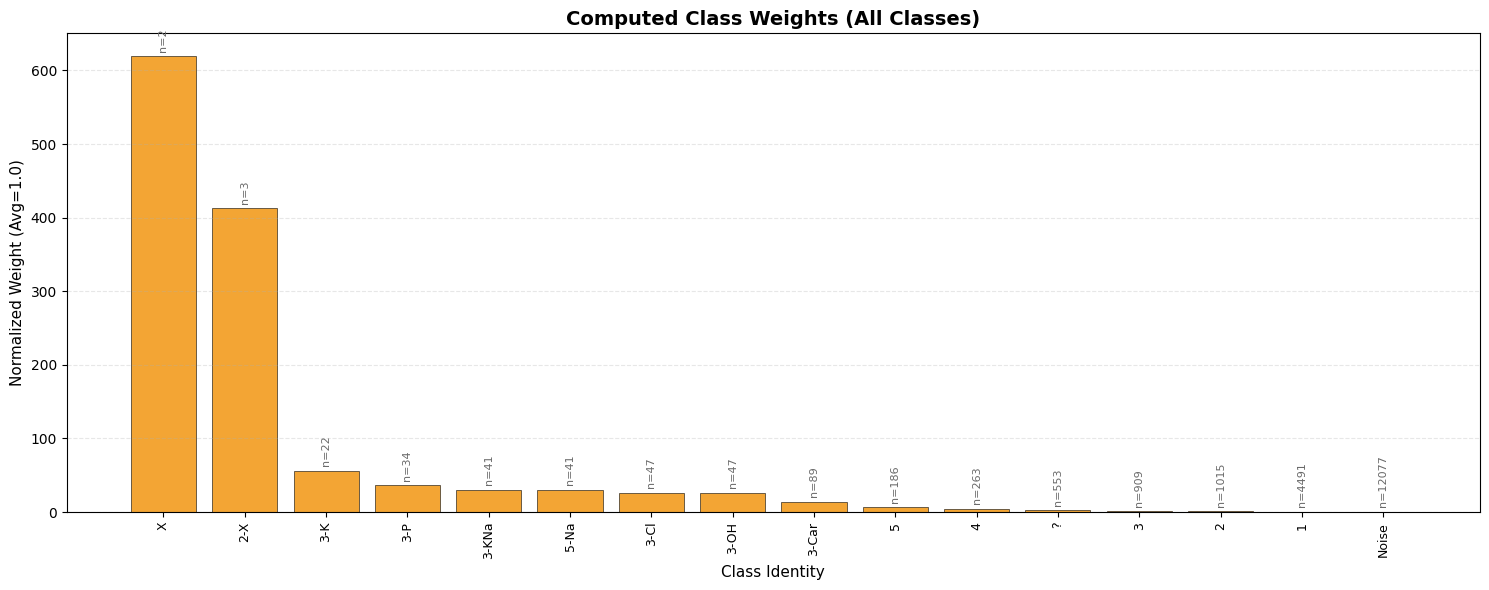

  ✓ Class weight visualization complete
DataLoader created.


In [15]:
# 2. Preprocessing Function
from sklearn.utils.class_weight import compute_class_weight

def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Denoising with Savitzky-Golay filter
        window_length = min(11, len(s) if len(s) % 2 == 1 else len(s) - 1)
        if window_length >= 5:
            s = savgol_filter(s, window_length=window_length, polyorder=3)
        
        # C. Log Transformation
        s = np.log1p(np.maximum(s, 0))
        
        # D. Max Normalization
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)
print(f"Processed Data Shape: {X_train.shape}")

# Calculate Class Weights to handle imbalance (Noise domination)
# Using sklearn.utils.class_weight.compute_class_weight (Standard for Keras/Scikit-learn)
print("Calculating class weights (Balanced)...")
sample_weights_tensor = None

if 'class' in df.columns:
    # 1. Compute balanced class weights using sklearn
    # weight = n_samples / (n_classes * np.bincount(y))
    y_train_classes = df['class'].values
    unique_classes = np.unique(y_train_classes)
    
    weights_per_class = compute_class_weight(
        class_weight='balanced', 
        classes=unique_classes, 
        y=y_train_classes
    )
    
    class_weights = dict(zip(unique_classes, weights_per_class))
    
    print("  Using Sklearn 'balanced' Class Weighting")
    
    # 2. Map back to samples for per-sample modification in Loss
    weights_np = df['class'].map(class_weights).values.astype(np.float32)
    
    # 3. Normalize so average weight is 1.0 (maintains loss scale)
    weights_np = weights_np / weights_np.mean()
    
    sample_weights_tensor = torch.from_numpy(weights_np)
    
    print(f"  Class weights generated. (Max weight: {weights_np.max():.2f}, Min weight: {weights_np.min():.2f})")
    
    # Show weights for rarest classes
    class_counts = df['class'].value_counts()
    rarest_classes = class_counts.tail(3).index.tolist()
    
    # Also show weight for most common class (likely Noise) if present
    if len(class_counts) > 0:
        most_common = class_counts.index[0]
        norm_weight_common = weights_np[df['class'] == most_common][0]
        print(f"    Most common ({most_common}): weight={norm_weight_common:.4f} (count={class_counts[most_common]})")
        
        for cls in rarest_classes:
             if cls in df['class'].values:
                norm_weight = weights_np[df['class'] == cls][0]
                print(f"    Rarest ({cls}): weight={norm_weight:.2f} (count={class_counts[cls]})")

    # --- VISUALIZATION OF WEIGHTS ---
    print("\n  Visualizing Class Weights...")
    plt.figure(figsize=(15, 6))
    
    # Prepare data
    viz_data = []
    for cls in unique_classes:
        cls_idx = np.where(df['class'].values == cls)[0][0]
        w = weights_np[cls_idx]
        count = class_counts[cls]
        viz_data.append({'Class': cls, 'Weight': w, 'Count': count})
    
    viz_df = pd.DataFrame(viz_data).sort_values('Weight', ascending=False)
    
    # Handle large number of classes
    if len(viz_df) > 35:
        top_n = 20
        bottom_n = 10
        spacer = pd.DataFrame([{'Class': '...', 'Weight': 0, 'Count': 0}])
        viz_subset = pd.concat([viz_df.head(top_n), spacer, viz_df.tail(bottom_n)])
        title_suffix = f"(Top {top_n} & Bottom {bottom_n} shown)"
    else:
        viz_subset = viz_df
        title_suffix = "(All Classes)"
        
    # Plot
    x_positions = range(len(viz_subset))
    bars = plt.bar(x_positions, viz_subset['Weight'], color='#F18F01', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    plt.title(f"Computed Class Weights {title_suffix}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Weight (Avg=1.0)", fontsize=11)
    plt.xlabel("Class Identity", fontsize=11)
    
    # Text annotations for counts
    max_y = viz_subset['Weight'].max()
    for i, (bar, row) in enumerate(zip(bars, viz_subset.itertuples())):
        if row.Class == '...': 
            continue
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max_y*0.01), 
                 f'n={row.Count}', ha='center', va='bottom', rotation=90, fontsize=8, color='dimgray')
                 
    plt.xticks(x_positions, viz_subset['Class'].astype(str), rotation=90, fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Class weight visualization complete")
         
else:
    print("  'class' column missing. Using uniform weights.")
    sample_weights_tensor = torch.ones(len(X_train))

# Create DataLoader
# Dataset now includes weights: (input, weight)
dataset = TensorDataset(torch.from_numpy(X_train).unsqueeze(1), sample_weights_tensor) 
loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
print("DataLoader created.")

### 3. TCN Autoencoder Architecture

We design a **Temporal Convolutional Network (TCN)** that acts as an autoencoder.

**Architecture Design Choices:**
1.  **Residual Blocks**: Each block consists of dilated convolutions + ReLU + Dropout + Residual connection. 
2.  **Dilations**: We use standard dilation steps ($2^i$) to expand the receptive field.
3.  **Less Aggressive Compression**: Instead of aggressively striding down to a tiny spatial dimension rapidly, we use pooling or stride more gently, preserving more temporal information before the bottleneck.
4.  **Parameter Efficiency**: We use Groups or Depthwise Separable logic if needed, but here we keep channel counts moderate (`[32, 64, 64, 128]`) to keep parameters low while "going deep" with layers.

**Encoder**: Input (1, 1000) $\to$ TCN Blocks $\to$ Flatten $\to$ Linear $\to$ Latent (128)
**Decoder**: Latent (128) $\to$ Linear $\to$ Reshape $\to$ Inverse TCN Blocks (Upsample + Conv) $\to$ Output (1, 1000)

In [16]:
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.relu1 = nn.LeakyReLU(Slope)
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=1, padding='same', dilation=dilation)
        self.relu2 = nn.LeakyReLU(Slope)
        self.dropout2 = nn.Dropout(dropout)
        
        self.net = nn.Sequential(self.conv1, self.relu1, self.dropout1,
                                 self.conv2, self.relu2, self.dropout2)
        
        # Downsample residual if dimensions change
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        
        self.stride = stride

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        
        if self.stride > 1 and self.downsample is None:
             res = res[:, :, ::self.stride]
        elif self.stride > 1 and self.downsample is not None:
             res = torch.nn.functional.interpolate(res, size=out.shape[2], mode='linear', align_corners=False)

        return self.relu2(out + res)


class TCNEncoder(nn.Module):
    def __init__(self, input_channels, num_channels, kernel_size=3, dropout=0.2):
        super(TCNEncoder, self).__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_channels if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            layers.append(
                TemporalBlock(in_inputs=in_channels, n_outputs=out_channels, 
                              kernel_size=kernel_size, stride=2, dilation=dilation_size,
                              padding=(kernel_size-1) * dilation_size // 2, dropout=dropout)
            )
            layers.append(
                nn.Sequential(
                    nn.Conv1d(in_channels, out_channels, kernel_size, stride=2, padding=kernel_size//2),
                    nn.BatchNorm1d(out_channels),
                    nn.LeakyReLU(Slope),
                    nn.Dropout(dropout)
                )
            )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TCNAutoEncoder(nn.Module):
    def __init__(self, input_len, latent_dim, channels, kernel_size):
        super(TCNAutoEncoder, self).__init__()
        
        # --- ENCODER ---
        self.encoder_layers = nn.ModuleList()
        current_channels = 1
        
        for ch in channels:
            # Block: Conv(stride=2) -> BN -> ReLU -> Dropout
            self.encoder_layers.append(
                nn.Sequential(
                    nn.Conv1d(current_channels, ch, kernel_size, stride=2, padding=kernel_size//2),
                    nn.BatchNorm1d(ch),
                    nn.LeakyReLU(Slope),
                    nn.Dropout(Dropout_Rate)
                )
            )
            current_channels = ch
            
        # Dynamically calculate flattened dimension
        self._calculate_flatten_dim(input_len)
        
        print(f"Flattened dimension before bottleneck: {self.flatten_dim} ({current_channels} x {self.final_len})")
        
        # Bottleneck
        self.bottleneck = nn.Linear(self.flatten_dim, latent_dim)
        
        # --- DECODER ---
        # Expand linear back to spatial
        self.decoder_input = nn.Linear(latent_dim, self.flatten_dim)
        self.decoder_reshape_ch = current_channels
        self.decoder_reshape_len = self.final_len
        
        self.decoder_layers = nn.ModuleList()
        reversed_channels = list(reversed(channels)) # e.g. [128, 64, 64, 32]
        
        # Iterate backwards
        for i in range(len(reversed_channels)):
            in_ch = reversed_channels[i]
            out_ch = reversed_channels[i+1] if i < len(reversed_channels)-1 else 1
            
            self.decoder_layers.append(
                nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
                    nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                    nn.BatchNorm1d(out_ch),
                    nn.LeakyReLU(Slope) if i < len(reversed_channels)-1 else nn.Sigmoid() 
                )
            )

    def _calculate_flatten_dim(self, input_len):
        # Create a dummy input to pass through encoder layers to get exact output size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_len)
            out = dummy_input
            for layer in self.encoder_layers:
                out = layer(out)
            
            self.final_len = out.shape[2]
            self.flatten_dim = out.numel() # Batch size is 1, so numel is flat dim

    def forward(self, x):
        # Encoder
        out = x
        for layer in self.encoder_layers:
            out = layer(out)
        
        # Flatten
        out = out.view(out.size(0), -1)
        
        # Bottleneck
        latent = self.bottleneck(out)
        
        # Decoder
        out = self.decoder_input(latent)
        out = out.view(out.size(0), self.decoder_reshape_ch, self.decoder_reshape_len)
        
        for layer in self.decoder_layers:
            out = layer(out)
            
        # Output crop/pad to match input length exactly
        if out.size(2) != x.size(2):
            out = torch.nn.functional.interpolate(out, size=x.size(2), mode='linear', align_corners=False)
            
        return out, latent


print("="*70)
print("TCN AutoEncoder Architecture")
print("="*70)

model = TCNAutoEncoder(
    input_len=Input_Length,
    latent_dim=Latent_Dim,
    channels=Channel_List,
    kernel_size=Kernel_Size
).to(device)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params:,}")

# Check compression ratio
input_dims = Input_Length
latent_dims = Latent_Dim
print(f"Compression: {input_dims} floats -> {latent_dims} floats (Ratio: {input_dims/latent_dims:.1f}x)")
print("="*70)

TCN AutoEncoder Architecture
Flattened dimension before bottleneck: 4096 (256 x 16)
TCNAutoEncoder(
  (encoder_layers): ModuleList(
    (0): Sequential(
      (0): Conv1d(1, 32, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
      (3): Dropout(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
      (3): Dropout(p=0.1, inplace=False)
    )
    (2): Sequential(
      (0): Conv1d(64, 64, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
      (3): Dropout(p=0.1, inplace=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_s

### 4. Training
We train using Mean Squared Error (MSE) weighted by the class importance (Noise samples matter less, Rare classes matter more).

In [17]:
# 4. Training Loop
optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)
criterion = nn.MSELoss(reduction='none') # We will apply weights manually

print("="*70)
print(f"Training TCN Autoencoder (Latent Dim: {Latent_Dim})")
print(f"Epochs: {Epochs}")
print("="*70)

for epoch in range(Epochs):
    model.train()
    total_loss = 0
    
    for batch in loader:
        img = batch[0].to(device)
        
        if len(batch) > 1:
            weights = batch[1].to(device)
        else:
            weights = torch.ones(img.size(0), device=device)
            
        optimizer.zero_grad()
        
        # Forward pass
        recon, latent = model(img)
        
        # Loss calculation: MSE per sample * Class Weight
        loss_per_sample = criterion(recon, img).mean(dim=[1, 2])
        weighted_loss = (loss_per_sample * weights).mean()
        
        weighted_loss.backward()
        optimizer.step()
        
        total_loss += weighted_loss.item()
        
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}/{Epochs}, Loss: {avg_loss:.6f}")

print("\n✓ Training complete!")

Training TCN Autoencoder (Latent Dim: 32)
Epochs: 20
Epoch 1/20, Loss: 0.047530
Epoch 1/20, Loss: 0.047530
Epoch 2/20, Loss: 0.034980
Epoch 2/20, Loss: 0.034980
Epoch 3/20, Loss: 0.027518
Epoch 3/20, Loss: 0.027518
Epoch 4/20, Loss: 0.024194
Epoch 4/20, Loss: 0.024194
Epoch 5/20, Loss: 0.019663
Epoch 5/20, Loss: 0.019663
Epoch 6/20, Loss: 0.017132
Epoch 6/20, Loss: 0.017132
Epoch 7/20, Loss: 0.014741
Epoch 7/20, Loss: 0.014741
Epoch 8/20, Loss: 0.013327
Epoch 8/20, Loss: 0.013327
Epoch 9/20, Loss: 0.012635
Epoch 9/20, Loss: 0.012635
Epoch 10/20, Loss: 0.011137
Epoch 10/20, Loss: 0.011137
Epoch 11/20, Loss: 0.009699
Epoch 11/20, Loss: 0.009699
Epoch 12/20, Loss: 0.009005
Epoch 12/20, Loss: 0.009005
Epoch 13/20, Loss: 0.010797
Epoch 13/20, Loss: 0.010797
Epoch 14/20, Loss: 0.007351
Epoch 14/20, Loss: 0.007351
Epoch 15/20, Loss: 0.006717
Epoch 15/20, Loss: 0.006717
Epoch 16/20, Loss: 0.007238
Epoch 16/20, Loss: 0.007238
Epoch 17/20, Loss: 0.006633
Epoch 17/20, Loss: 0.006633
Epoch 18/20, 

### 5. Evaluation & Latent Space Visualization
We extract the latent vectors and evaluate clustering quality using Silhouette Score and Linear Probing, identical to the VQ-VAE notebook.

Extracting latent space (Batched)...
Latent space shape: (19820, 32)
Mean reconstruction error: 0.012554

EVALUATION
Latent space shape: (19820, 32)
Mean reconstruction error: 0.012554

EVALUATION
Latent Silhouette Score: -0.0230
Running Linear Probe (3-fold CV)...
Latent Silhouette Score: -0.0230
Running Linear Probe (3-fold CV)...
Linear Probe F1: 0.8857 ± 0.0009
Running k-NN Consistency Check (k=5)...
Linear Probe F1: 0.8857 ± 0.0009
Running k-NN Consistency Check (k=5)...
k-NN Neighbors Accuracy: 0.9138 ± 0.0014
  (Higher is better: means neighbors share the same class)

Generating t-SNE Visualization...
Subsampling for t-SNE (N=10000)...
k-NN Neighbors Accuracy: 0.9138 ± 0.0014
  (Higher is better: means neighbors share the same class)

Generating t-SNE Visualization...
Subsampling for t-SNE (N=10000)...


/var/folders/c0/h7rcgjdd7p35pczt_n1jjp8h0000gn/T/ipykernel_795/686213300.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(unique_cls))


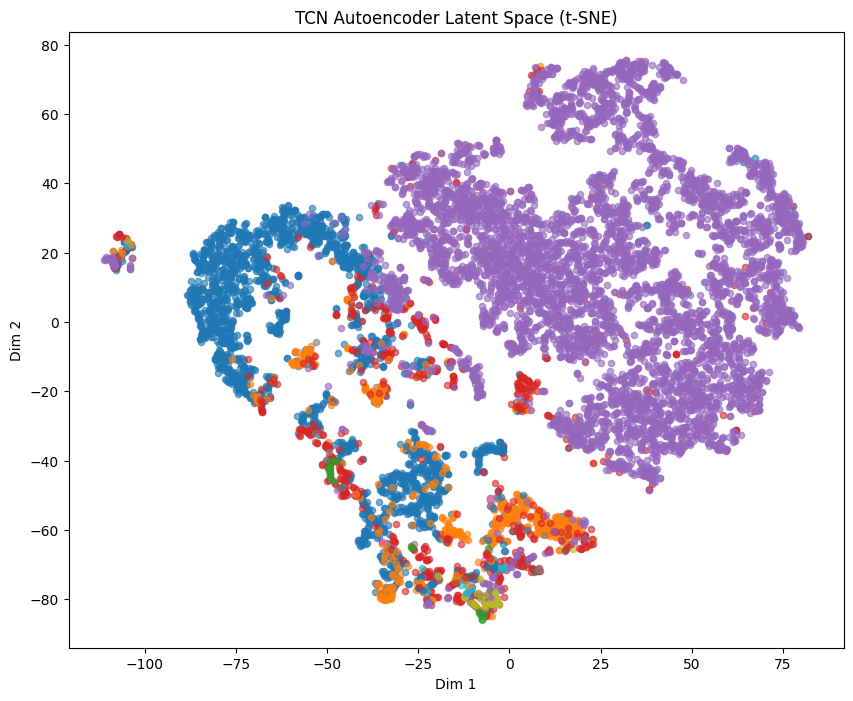


Generating 3D Visualization (PCA)...


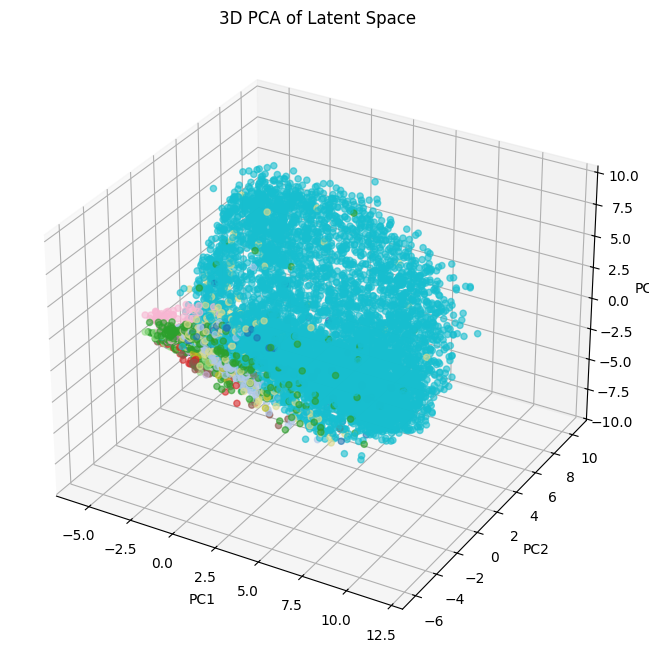

In [18]:
# 5. Extract Latent Space
model.eval()

# Use a sequential loader to ensure order matches df
inference_dataset = TensorDataset(torch.from_numpy(X_train).unsqueeze(1))
inference_loader = DataLoader(inference_dataset, batch_size=Batch_Size, shuffle=False)

latent_list = []
recon_error_list = []

print("Extracting latent space (Batched)...")
with torch.no_grad():
    for batch in inference_loader:
        img = batch[0].to(device)
        reconstructed, latent_vectors = model(img)
        
        latent_list.append(latent_vectors.cpu().numpy())
        
        # Calculate MSE per sample
        batch_error = torch.mean((img - reconstructed) ** 2, dim=[1, 2])
        recon_error_list.append(batch_error.cpu().numpy())

latent_flat = np.concatenate(latent_list, axis=0)
reconstruction_error = np.concatenate(recon_error_list, axis=0)

df['recon_error'] = reconstruction_error
print(f"Latent space shape: {latent_flat.shape}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")

# 5.1 Ground Truth Evaluation Metrics
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("\n" + "="*70)
print("EVALUATION")
print("="*70)

# Global Normalization for Visualization (t-SNE/PCA)
scaler = StandardScaler()
latent_normalized = scaler.fit_transform(latent_flat)

if 'class' in df.columns:
    ground_truth_labels = df['class'].values
    le = LabelEncoder()
    y_encoded = le.fit_transform(ground_truth_labels)

    # Filter classes for Metric Calculation (min 5 samples for CV)
    class_counts = pd.Series(ground_truth_labels).value_counts()
    valid_classes = class_counts[class_counts >= 5].index
    valid_mask = df['class'].isin(valid_classes)

    # Use normalized latent vectors for metrics
    latent_valid = latent_normalized[valid_mask]
    y_valid = y_encoded[valid_mask]

    # Metric 1: Silhouette
    if len(np.unique(y_valid)) > 1:
        score = silhouette_score(latent_valid, y_valid)
        print(f"Latent Silhouette Score: {score:.4f}")
    
    # Metric 2: Linear Probe (Global separability)
    print("Running Linear Probe (3-fold CV)...")
    clf = LogisticRegression(max_iter=1000, solver='saga')
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, latent_valid, y_valid, cv=cv, scoring='f1_weighted')
    print(f"Linear Probe F1: {scores.mean():.4f} ± {scores.std():.4f}")

    # Metric 3: k-NN Consistency (Local neighborhood quality)
    # Checks if nearest neighbors belong to the same class
    print("Running k-NN Consistency Check (k=5)...")
    knn = KNeighborsClassifier(n_neighbors=5)
    knn_scores = cross_val_score(knn, latent_valid, y_valid, cv=cv, scoring='accuracy')
    print(f"k-NN Neighbors Accuracy: {knn_scores.mean():.4f} ± {knn_scores.std():.4f}")
    print("  (Higher is better: means neighbors share the same class)")

else:
    print("No class labels for evaluation.")

# 5.2 Visualization (t-SNE)
print("\nGenerating t-SNE Visualization...")
# Use a subset if data is huge to speed up t-SNE
if len(latent_normalized) > 10000:
    print("Subsampling for t-SNE (N=10000)...")
    indices = np.random.choice(len(latent_normalized), 10000, replace=False)
    latent_for_tsne = latent_normalized[indices]
    if 'class' in df.columns:
        labels_for_tsne = df['class'].values[indices]
else:
    latent_for_tsne = latent_normalized
    if 'class' in df.columns:
        labels_for_tsne = df['class'].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(latent_for_tsne)

plt.figure(figsize=(10, 8))
if 'class' in df.columns:
    unique_cls = np.unique(labels_for_tsne)
    # Handle colormap assignment
    colors = cm.get_cmap('tab20', len(unique_cls))
    
    for i, cls in enumerate(unique_cls):
        mask = labels_for_tsne == cls
        plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1], 
                    label=cls, s=20, alpha=0.6)
    
    if len(unique_cls) <= 15:
        plt.legend()
else:
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5)

plt.title("TCN Autoencoder Latent Space (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

# 5.3 3D Visualization (PCA)
print("\nGenerating 3D Visualization (PCA)...")
pca_3d = PCA(n_components=3)
pca_result = pca_3d.fit_transform(latent_normalized)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if 'class' in df.columns:
    # Use all data for PCA plot
    ground_truth_labels_all = df['class'].values
    unique_all = np.unique(ground_truth_labels_all)
    c_map = {cls: i for i, cls in enumerate(unique_all)}
    colors_list = [c_map[c] for c in ground_truth_labels_all]
    
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], 
               c=colors_list, cmap='tab20', s=20, alpha=0.6)
else:
    ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], alpha=0.6)

ax.set_title("3D PCA of Latent Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()